In [1]:
# Imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load preprocessed data
data = np.load('data/processed_data.npz')
X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Matplotlib is building the font cache; this may take a moment.


Using device: cpu
Train: (158400, 2, 128), Val: (17600, 2, 128), Test: (44000, 2, 128)


In [2]:
class CNN1D(nn.Module):
    def __init__(self, num_classes=11):
        super(CNN1D, self).__init__()
        
        # Conv layers
        self.conv1 = nn.Conv1d(2, 64, kernel_size=8, padding='same')
        self.conv2 = nn.Conv1d(64, 64, kernel_size=8, padding='same')
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.5)
        
        # After 2 pools: 128 -> 64 -> 32
        self.fc1 = nn.Linear(64 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # x shape: (batch, 2, 128)
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)
        
        x = x.view(x.size(0), -1)  # flatten
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Test the model
model = CNN1D(num_classes=11).to(device)
dummy = torch.randn(4, 2, 128).to(device)
out = model(dummy)
print(f"Model output shape: {out.shape}")
print(f"\nModel architecture:")
print(model)

Model output shape: torch.Size([4, 11])

Model architecture:
CNN1D(
  (conv1): Conv1d(2, 64, kernel_size=(8,), stride=(1,), padding=same)
  (conv2): Conv1d(64, 64, kernel_size=(8,), stride=(1,), padding=same)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=11, bias=True)
)


C:\Users\nabee\anaconda3\envs\amc\lib\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1025.)
  return F.conv1d(


In [3]:
# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.LongTensor(y_val)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test)

# Create datasets and loaders
batch_size = 128

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 1238
Val batches: 138
Test batches: 344


In [4]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        
        for X_batch, y_batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == y_batch).sum().item()
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == y_batch).sum().item()
        
        # Record metrics
        train_loss /= len(train_loader)
        train_acc = train_correct / len(train_loader.dataset)
        val_loss /= len(val_loader)
        val_acc = val_correct / len(val_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f'Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}')
    
    return history

print("Training function defined.")

Training function defined.


In [5]:
# Train the model
model = CNN1D(num_classes=11).to(device)
history = train_model(model, train_loader, val_loader, epochs=15, lr=0.001)

# Save the model
torch.save(model.state_dict(), 'models/cnn_model.pt')
print("\nModel saved to models/cnn_model.pt")

Epoch 1: Train Loss=2.2264, Train Acc=0.1610, Val Loss=1.8827, Val Acc=0.2934


Epoch 2: Train Loss=1.8554, Train Acc=0.3017, Val Loss=1.7210, Val Acc=0.3520


Epoch 3: Train Loss=1.7559, Train Acc=0.3402, Val Loss=1.6473, Val Acc=0.3744


Epoch 4: Train Loss=1.7018, Train Acc=0.3620, Val Loss=1.5939, Val Acc=0.4041


Epoch 5: Train Loss=1.6602, Train Acc=0.3798, Val Loss=1.5502, Val Acc=0.4245


...

Epoch 11: Train Loss=1.4894, Train Acc=0.4344, Val Loss=1.3725, Val Acc=0.4730


Epoch 12: Train Loss=1.4735, Train Acc=0.4383, Val Loss=1.3660, Val Acc=0.4762


Epoch 13: Train Loss=1.4546, Train Acc=0.4456, Val Loss=1.3534, Val Acc=0.4738


Epoch 14: Train Loss=1.4414, Train Acc=0.4496, Val Loss=1.3407, Val Acc=0.4890


Epoch 15: Train Loss=1.4251, Train Acc=0.4543, Val Loss=1.3169, Val Acc=0.4925

Model saved to models/cnn_model.pt


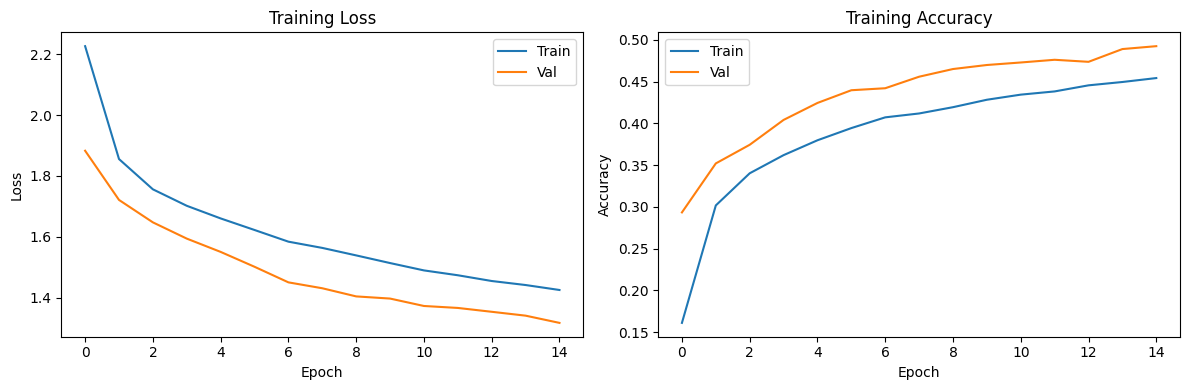

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/cnn_training_curves.png', dpi=150)
plt.show()

In [7]:
# Evaluate on test set
model.eval()
test_correct = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Test Accuracy: 0.4975 (49.75%)


SNR -20 dB: 0.1000
SNR -18 dB: 0.0985
SNR -16 dB: 0.1014
SNR -14 dB: 0.1105
SNR -12 dB: 0.1063
SNR -10 dB: 0.1678
SNR  -8 dB: 0.2891
SNR  -6 dB: 0.4563
SNR  -4 dB: 0.6028
SNR  -2 dB: 0.6312
SNR   0 dB: 0.6741
SNR   2 dB: 0.7229
SNR   4 dB: 0.7277
SNR   6 dB: 0.7347
SNR   8 dB: 0.7267
SNR  10 dB: 0.7276
SNR  12 dB: 0.7442
SNR  14 dB: 0.7316
SNR  16 dB: 0.7346
SNR  18 dB: 0.7444


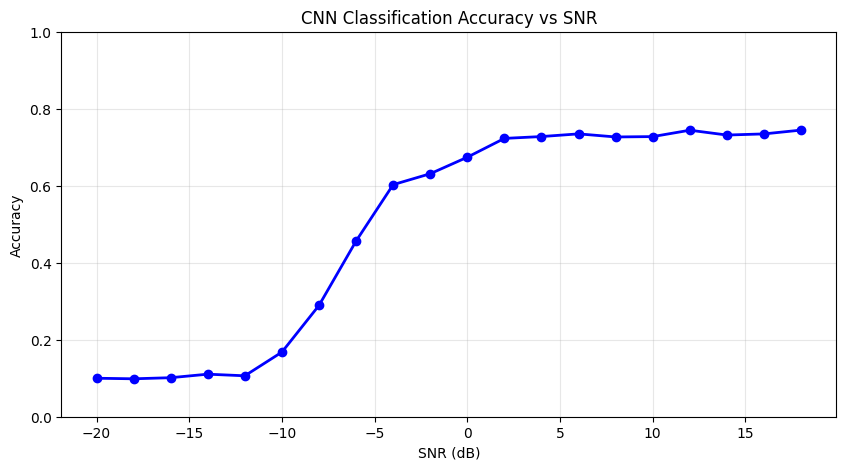

In [8]:
# Load SNR labels for test set
snr_test = np.load('data/processed_data.npz')['snr_test']

# Calculate accuracy per SNR
snr_values = sorted(list(set(snr_test)))
snr_accs = []

for snr in snr_values:
    mask = snr_test == snr
    snr_acc = (all_preds[mask] == all_labels[mask]).mean()
    snr_accs.append(snr_acc)
    print(f"SNR {snr:3d} dB: {snr_acc:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(snr_values, snr_accs, 'bo-', linewidth=2, markersize=6)
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('CNN Classification Accuracy vs SNR')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])
plt.savefig('figures/cnn_accuracy_vs_snr.png', dpi=150)
plt.show()

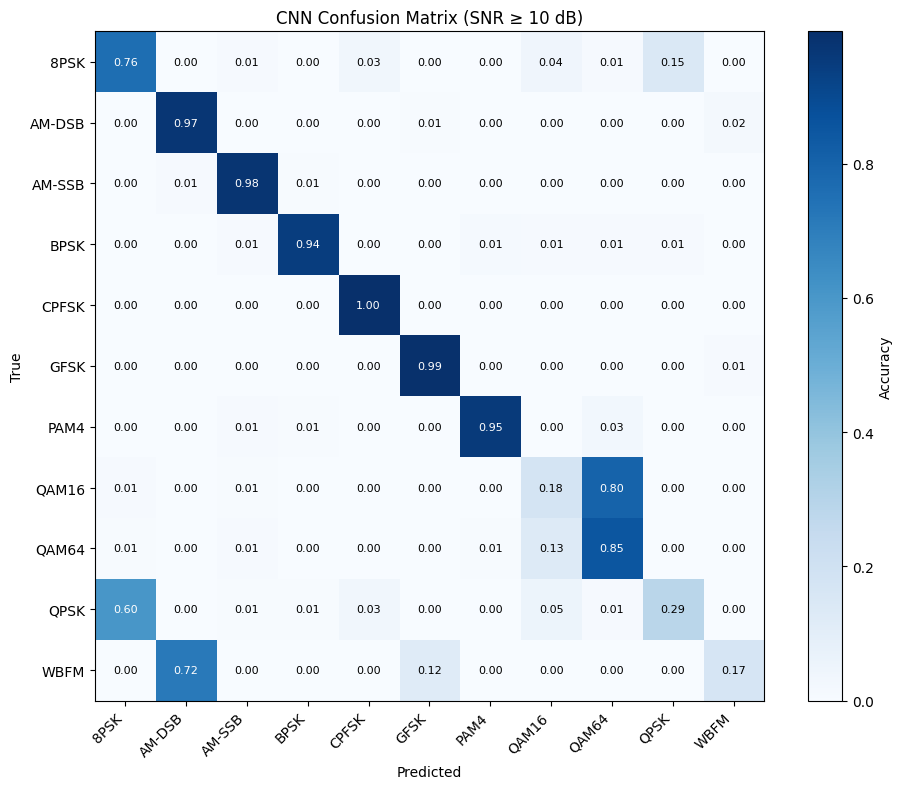

In [9]:
from sklearn.metrics import confusion_matrix
import json

# Load label mapping
with open('data/label_mapping.json', 'r') as f:
    mod_to_label = json.load(f)
label_to_mod = {v: k for k, v in mod_to_label.items()}
class_names = [label_to_mod[i] for i in range(11)]

# Confusion matrix for high SNR only (≥ 10 dB)
high_snr_mask = snr_test >= 10
cm = confusion_matrix(all_labels[high_snr_mask], all_preds[high_snr_mask])

# Normalize by row (true labels)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Plot
plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, interpolation='nearest', cmap='Blues')
plt.colorbar(label='Accuracy')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN Confusion Matrix (SNR ≥ 10 dB)')
plt.xticks(range(11), class_names, rotation=45, ha='right')
plt.yticks(range(11), class_names)

# Add text annotations
for i in range(11):
    for j in range(11):
        plt.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                color='white' if cm_norm[i,j] > 0.5 else 'black', fontsize=8)

plt.tight_layout()
plt.savefig('figures/cnn_confusion_matrix.png', dpi=150)
plt.show()